
# The N-Body Simulator

As the name suggests (and as anyone with a cursory interest in physics would know), the objective of the N-body simulation problem is to model the time evolution of a system of N bodies only interacting through the gravitational force given an initial state. Only the 2-body problem can be completely solved - and in the case of very many bodies, such as in the case of modeling galaxy evolution and interactions, this problem becomes quite computationally intensive by a naive approach.

## Formulation

In our case, we will consider the 2D formulation.

We have $n$ point masses in an inertial reference frame, each with mass $m_1,m_2,...m_n$ and position vectors $\vec{r_1},\vec{r_2},...,\vec{r_m}$ only interacting by gravitational force, $$F_{ij} = \frac{Gm_im_j(\vec{r_j}-\vec{r_i})}{||\vec{r_j}-\vec{r_i}||^3}$$
The total gravitational force on mass $i$ is $$F_i = \sum_{j=1, j\neq i}^{n}\frac{Gm_im_j(\vec{r_j}-\vec{r_i})}{||\vec{r_j}-\vec{r_i}||^3}$$

Since the acceleration is second-degree, we should rewrite it in terms of the velocity so we get first-degree for use in RK4.

Our state vector $y$ is then $$y = (\vec{r_1}, \vec{r_2},...,\vec{r_n},\vec{v_1},...,\vec{v_n})$$

For each RK4 step, we use the previous step's velocities to perturb the positions of the current step, then perturb the velocities based on the newly calculated distances & forces.

To avoid extreme wonkiness with particles becoming attracted to each other and then slinging each other at massive speed in away from one another, I've added a softening parameter - instead of $\frac{1}{r^2}$ in the force law, we do $\frac{1}{r^2 + \epsilon^2}$, effectively a "minimum distance." This does mean our force is technically not Newtonian gravity, but it's close enough.

Additionally, If two particles are within a certain value, then they will be merged, obeying momentum conservation.
This is accomplished via creating a DSU during force calculation, then merging masses afterwards.

For the Barnes-Hut implementation, we'll first build a tree by subdividing space. Every time we subdivide, we also store the COM, total mass, and width in that node. Then, for each body, we traverse the tree. When we traverse a node, we determine if its $/theta$ is appropriate to use as a point mass - if so, we add its contribution as a point mass to the total force on the body and return. If it isn't, we'll instead return the sum of its child traversals.

RadioButtons(description='Force simulation method:', options=(('Naive', 0), ('Basic Barnes-Hut', 1), ('Modifie…

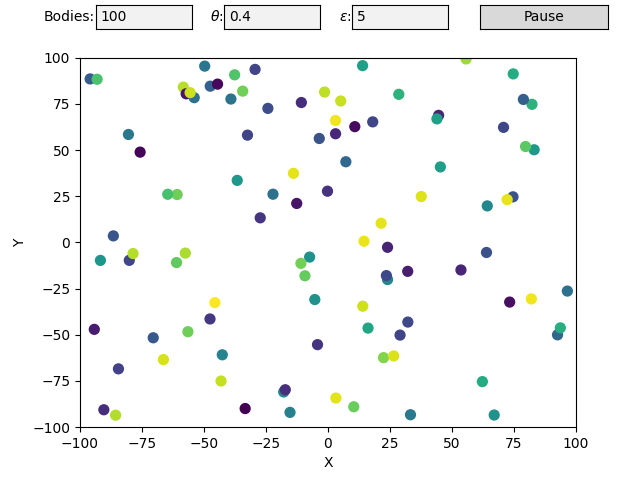

1

In [1]:
from matplotlib.widgets import TextBox
%matplotlib widget
from matplotlib import pyplot as plt, animation as anim
import numpy as np
import ipywidgets as widgets
from IPython.display import display

class Node:
    __slots__ = ("mx", "my", "size", "mass", "comx", "comy", "children", "bodies")
UL = 100 #universe length (well technically half)
MAXDEPTH = 40 #max depth of the BH tree
THETA = 0.4 #it is in fact theta
rng = np.random.default_rng() #formerly seeded 123456 for debugging reasons
bodies = 100 #now this is a decent amount
fig, ax = plt.subplots()
G = 6.67 * 1E-4
DT = 1E-2 #the scaling for time, a debug tool.
ELAT = 0
X0 = (rng.random(size=bodies) * 2 * UL) - UL #stores x-coordinates. Randomly generated at the start.
VX0 = (rng.random(size=bodies) * 0.03 * UL) - (0.015 * UL) #stores x-velocity
Y0 = (rng.random(size=bodies) * 2 * UL) - UL #stores y-coordinates. Randomly generated at the start.
VY0 = (rng.random(size=bodies) * 0.03 * UL) - (0.015 * UL) #stores y-velocity
M = np.full(bodies,500000) #stores masses. Same mass for all, at least for now.
stop = False

#these are copies of the original positions for when we reset the sim
X00 = X0
VX00 = VX0
Y00 = Y0
VY00 = VY0
method = 0 #stores the current simulation type (0 - naive, 1 - BH, 2 - improved BH)
C = np.random.random(bodies)


#UI stuff
gplot = plt.scatter(X0, Y0, c = C, s = 50)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xlim([-UL,UL])
ax.set_ylim([-UL,UL])
softening = 5 #a "minimum distance" so the particles don't zoom - a stopgap before merging



def reroll(text):
    global bodies, X0, VX0, Y0, VY0, X00, VX00, Y00, VY00, ELAT, M
    try:
        newBodies = int(text)
        if newBodies > 0:
            bodies = newBodies
            ELAT = 0
            X0 = (rng.random(size=bodies) * 2 * UL) - UL
            VX0 = (rng.random(size=bodies) * 0.03 * UL) - (0.015 * UL)
            Y0 = (rng.random(size=bodies) * 2 * UL) - UL
            VY0 = (rng.random(size=bodies) * 0.03 * UL) - (0.015 * UL)
            M = np.full(bodies,500000)
            X00 = X0
            VX00 = VX0
            Y00 = Y0
            VY00 = VY0
            ELAT = 0
        return
    except ValueError:
        return
def updateTheta(text):
    global THETA
    try:
        THETA = float(text)
        return
    except ValueError:
        return
def updateSoft(text):
    global softening
    try:
        softening = float(text)
        return
    except ValueError:
        return
energy_label = ax.text(
    0.98, 1.05, "",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10, family="monospace",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)  # optional readability backing
)
time_label = ax.text(
    0.2, 1.05, "",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10, family="monospace",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)  # optional readability backing
)
effForces_label = ax.text(
    0.6, 1.05, "",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10, family="monospace",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)  # optional readability backing
)

methodSelect = widgets.RadioButtons(options=[('Naive', 0), ('Basic Barnes-Hut',1), ('Modified Barnes-Hut', 2)],description='Force simulation method:', disabled=False, continuous=True,)
display(methodSelect)

#the interactables

axbox = plt.axes([0.15, 0.94 , 0.15, 0.05])
bodiesbox = TextBox(axbox, 'Bodies:', initial="100")
bodiesbox.on_submit(reroll)

axth = plt.axes([0.35, 0.94 , 0.15, 0.05])
thetabox = TextBox(axth, '$\\theta$:', initial="0.4")
thetabox.on_submit(updateTheta)

axsf = plt.axes([0.55, 0.94 , 0.15, 0.05])
softbox = TextBox(axsf, '$\\epsilon$:', initial="5")
softbox.on_submit(updateSoft)

axst = plt.axes([0.75, 0.94 , 0.2, 0.05])
stopbut = plt.Button(axst, 'Pause')

running = True
def toggle(event):
    global running
    if running:
        ani.pause()
        stopbut.label.set_text("Resume")
    else:
        ani.resume()
        stopbut.label.set_text("Pause")
    running = not running
    fig.canvas.draw_idle()

stopbut.on_clicked(toggle)


#simulation methods

def buildNode(id, mx, my, size, X, Y, depth):
    global M
    node = Node()
    node.mx, node.my, node.size = mx, my, size
    Mn = M[id] # id contains the indices of the elements in this quadrant, M[id] is the subarray of M containing only those indices
    node.mass = Mn.sum()
    node.comx = (Mn * X[id]).sum() / node.mass #check out that efficiency
    node.comy = (Mn * Y[id]).sum() / node.mass
    node.children = []
    node.bodies = None #only if this is a leaf will we include all the body IDs
    if depth >= MAXDEPTH or len(id) == 1:
        node.bodies = id
        return node
    right = X[id] >= mx #this creates an array of the elements of X whose indices are in id[], and whose values in X are >= mx. Real array trickery.
    top = Y[id] >= my
    q = size/4
    for r in (True,False):
        for t in (True,False):
            qa = id[(right == r) & (top == t)] #right == r returns a bool array, the ith element of which corresponds to right[i] == r.
            if len(qa) > 0: #if this quadrant is non-empty, recursive call
                node.children.append(buildNode(qa, mx + (q if r else -q), my + (q if t else -q), size/2, X, Y, depth+1))
    return node

def buildTree(X,Y):
    mx = (X.max()- X.min())/2
    my = (Y.max()- Y.min())/2
    size = max(X.max() - X.min(), Y.max() - Y.min()) * 1.001 + 1E-12 #extra padding just in case stuff sits on the edge
    return buildNode(np.arange(bodies), mx, my, size, X, Y, 0)

def bh_sim(n, node, X, Y):
    if node.bodies is not None: #this means we have a leaf and must directly simulate the gravity
        forces = np.array([0,0])
        for i in node.bodies:
            if i != n:
                deltaX = X[i] - X[n]
                deltaY = Y[i] - Y[n]
                r_sq = deltaX * deltaX + deltaY * deltaY + softening * softening
                Fg = (G*M[i]*M[n]/r_sq)
                forces[0] += Fg*(deltaX/np.sqrt(r_sq))
                forces[1] += Fg*(deltaY/np.sqrt(r_sq))
        return forces, len(node.bodies)
    #this section is for non-leaves
    dx = node.comx - X[n]
    dy = node.comy - Y[n]
    d = np.sqrt((dx * dx) + (dy * dy))
    contains_n = abs(X[n] - node.mx) <= (node.size / 2) and abs(Y[n] - node.my) <= (node.size / 2) #if our mass n is within the quadrant
    if (not contains_n) and node.size < THETA * d: #treat it as a point mass!
        forces = np.array([0,0])
        r_sq = dx*dx + dy*dy + softening*softening
        Fg = (G*node.mass*M[n]/r_sq) #for some reason i square rooted this...
        forces[0] = Fg * (dx/np.sqrt(r_sq))
        forces[1] = Fg * (dy/np.sqrt(r_sq))
        return forces, 1
    #recurse
    forces = np.array([0,0])
    ef = 0
    for c in node.children:
        forcec, efc= bh_sim(n, c, X, Y)
        forces+=forcec
        ef+=efc
    return forces, ef
def bh_sim_improved(n, node, X, Y):
    if node.bodies is not None: #this means we have a leaf and must directly simulate the gravity
        forces = np.array([0,0])
        for i in node.bodies:
            if i != n:
                deltaX = X[i] - X[n]
                deltaY = Y[i] - Y[n]
                r_sq = deltaX * deltaX + deltaY * deltaY + softening * softening
                Fg = (G*M[i]*M[n]/r_sq)
                forces[0] += Fg*(deltaX/np.sqrt(r_sq))
                forces[1] += Fg*(deltaY/np.sqrt(r_sq))
        return forces, len(node.bodies)
    #this section is for non-leaves
    dx = node.comx - X[n]
    dy = node.comy - Y[n]
    d = np.sqrt((dx * dx) + (dy * dy))
    contains_n = abs(X[n] - node.mx) <= (node.size / 2) and abs(Y[n] - node.my) <= (node.size / 2) #if our mass n is within the quadrant
    delta = np.hypot(abs(node.comx - node.mx), abs(node.comy - node.my))
    if (not contains_n) and node.size / THETA  + delta < d: #treat it as a point mass!
        forces = np.array([0,0])
        r_sq = dx*dx + dy*dy + softening*softening
        Fg = (G*node.mass*M[n]/r_sq) #for some reason i square rooted this...
        forces[0] = Fg * (dx/np.sqrt(r_sq))
        forces[1] = Fg * (dy/np.sqrt(r_sq))
        return forces, 1
    #recurse
    forces = np.array([0,0])
    ef = 0
    for c in node.children:
        forcec, efc= bh_sim_improved(n, c, X, Y)
        forces+=forcec
        ef+=efc
    return forces, ef
def naive_sim(n, X, Y): #calculates forces on an object naively
    forces = [0,0]
    for i in range(bodies):
        if i != n:
            deltaX = X[i] - X[n]
            deltaY = Y[i] - Y[n]
            r_sq = deltaX * deltaX + deltaY * deltaY + softening * softening
            Fg = (G*M[i]*M[n]/r_sq)
            forces[0] += Fg*(deltaX/np.pow(r_sq,0.5))
            forces[1] += Fg*(deltaY/np.pow(r_sq,0.5))
    return forces
def rk4_naive(): #the great integration
    global X0, Y0, VX0, VY0, bodies, DT, ELAT
    y = np.array([X0, Y0, VX0, VY0])
    AX1 = []
    AY1 = []
    for i in range(bodies):
        forces = naive_sim(i,X0,Y0)
        AX1.append(forces[0]/M[i])
        AY1.append(forces[1]/M[i])
    states = np.array([[VX0,VY0,AX1,AY1]])#this array holds all the k's
    for i in range (1,4):
        tf = 0.5
        if i == 3:
            tf = 1
        yn = y + (states[i-1] * tf * DT)
        AXN = []
        AYN = []
        for k in range(bodies):
            forces = naive_sim(k,yn[0],yn[1])
            AXN.append(forces[0]/M[k])
            AYN.append(forces[1]/M[k])
        ns = np.array([[yn[2],yn[3],AXN,AYN]])
        states = np.concatenate((states,ns), axis = 0)
    yf = y + (DT/6) * (states[0] + (2*states[1]) + (2*states[2]) + states[3])
    X0 = yf[0]
    Y0 = yf[1]
    VX0 = yf[2]
    VY0 = yf[3]
    ELAT+=DT
    return 4 * (bodies-1) * (bodies-1)
def rk4_bh(): #the great integration, now with tree
    global X0, Y0, VX0, VY0, bodies, DT, ELAT
    y = np.array([X0, Y0, VX0, VY0])
    AX1 = []
    AY1 = []
    effForces = 0
    head = buildTree(X0,Y0)
    for i in range(bodies):
        forces, ef1 = bh_sim(i,head,X0,Y0)
        effForces+=ef1
        AX1.append(forces[0]/M[i])
        AY1.append(forces[1]/M[i])
    states = np.array([[VX0,VY0,AX1,AY1]])#this array holds all the k's
    for i in range (1,4):
        tf = 0.5
        if i == 3:
            tf = 1
        yn = y + (states[i-1] * tf * DT)
        AXN = []
        AYN = []
        headn = buildTree(yn[0],yn[1])
        for k in range(bodies):
            forces, efn = bh_sim(k,headn,yn[0],yn[1])
            effForces+=efn
            AXN.append(forces[0]/M[k])
            AYN.append(forces[1]/M[k])
        ns = np.array([[yn[2],yn[3],AXN,AYN]])
        states = np.concatenate((states,ns), axis = 0)
    yf = y + (DT/6) * (states[0] + (2*states[1]) + (2*states[2]) + states[3])
    X0 = yf[0]
    Y0 = yf[1]
    VX0 = yf[2]
    VY0 = yf[3]
    ELAT+=DT
    return effForces
def rk4_bh_improved(): #the great integration, now with tree
    global X0, Y0, VX0, VY0, bodies, DT, ELAT
    y = np.array([X0, Y0, VX0, VY0])
    AX1 = []
    AY1 = []
    effForces = 0
    head = buildTree(X0,Y0)
    for i in range(bodies):
        forces, ef1 = bh_sim_improved(i,head,X0,Y0)
        effForces+=ef1
        AX1.append(forces[0]/M[i])
        AY1.append(forces[1]/M[i])
    states = np.array([[VX0,VY0,AX1,AY1]])#this array holds all the k's
    for i in range (1,4):
        tf = 0.5
        if i == 3:
            tf = 1
        yn = y + (states[i-1] * tf * DT)
        AXN = []
        AYN = []
        headn = buildTree(yn[0],yn[1])
        for k in range(bodies):
            forces, efn = bh_sim_improved(k,headn,yn[0],yn[1])
            effForces+=efn
            AXN.append(forces[0]/M[k])
            AYN.append(forces[1]/M[k])
        ns = np.array([[yn[2],yn[3],AXN,AYN]])
        states = np.concatenate((states,ns), axis = 0)
    yf = y + (DT/6) * (states[0] + (2*states[1]) + (2*states[2]) + states[3])
    X0 = yf[0]
    Y0 = yf[1]
    VX0 = yf[2]
    VY0 = yf[3]
    ELAT+=DT
    return effForces
def getE():
    global X0, Y0, VX0, VY0, bodies
    ke = 0
    for i in range(bodies):
        ke += M[i] * 0.5 * ((VX0[i] * VX0[i]) + (VY0[i] * VY0[i]))
    pe = 0
    for k in range(bodies-1):
        for j in range(k+1,bodies):
            deltaX = X0[k] - X0[j]
            deltaY = Y0[k] - Y0[j]
            r_sq = deltaX * deltaX + deltaY * deltaY + softening * softening
            pe += ((-G * M[k]*M[j])/(np.pow(r_sq,0.5)))
    return ke + pe
def update(frame):
    global X0, Y0,VX0, VY0, ELAT, method, stop
    if method != methodSelect.value:
        X0 = X00
        Y0 = Y00
        ELAT = 0
        VX0 = VX00
        VY0 = VY00
        method = methodSelect.value
    match method:
        case 0:
            fw = rk4_naive()
        case 1:
            fw = rk4_bh()
        case 2:
            fw = rk4_bh_improved()
    gplot.set_offsets(np.column_stack([X0, Y0]))
    energy_label.set_text(f"E = {getE():.4e}")
    time_label.set_text(f"t = {ELAT:.4e}")
    effForces_label.set_text(f"effForces = {fw}")
    return gplot, energy_label

ani = anim.FuncAnimation(fig, update, frames=200, interval = 100,blit=True)
plt.show()
stopbut.on_clicked(ani.pause())


# Optimizing BH

As you can guess, moving away from a naive sim means compromises are being made. As my logic design professor said last quarter, "If you got an improvement in one area without losing anything, your original design was trash." So, what are we losing?

## Barnes-Hut Problems
Naturally, moving from direct simulation of all forces to an approximate model means we lose accuracy. Thus, we can expect to violate energy conservation over time. We can play with $\theta$ and the softening length to meet our specific system's regimes of course, but some optimizations remain:

### Multipole Expansion
Rather than only approximating as a point charge/mass, we can also include the second moment. More terms in the force calculation.

### Opening Criterion Changes
Basic Barnes-Hut only looks at the ratio $\frac{s}{d}$. But, this ignores situations where the COM is off to a far side of the cell and a lot of mass is on the closer side of the cell. To alleviate this, instead of using just $\frac{s}{d}$, we define a $\delta$ as the distance between the COM and the geometric center of the quadrant, then use $\frac{s + \delta \theta}{d} < \theta$.

With these improvements, a well-tuned BH should be able to accurately simulate the N-body problem.

## Non-BH problems

Python. Overheads. The naive solution is actually faster despite higher asymptotic complexity in this small-$N$ domain $(100)$. This is just due to Python overheads in recursion. For "fun" I ran this at N=1000, the optimized Barnes-Hut was able to crank out 1E-2 seconds of sim time in about 10 seconds of real time, while the naive was able to do that in 20 seconds, so the crossing point is somewhere around there, probably in the 800 or so range.

I'll probably end up rewriting this in my native C++ at some point so we don't have to deal with this. How to animate it without matplotlib, I don't know.